In [1]:
%config InlineBackend.figure_format = 'retina'
%load_ext autoreload
%autoreload 2

In [2]:
import polars as pl
from pathlib import Path
import waxwing
waxwing.set_figsize(8,3)

In [3]:
dataset_meta = pl.read_excel(
    "../datasets/butterfly-data-paper-slim/1_raw_data/program-permissions-table.xlsx"
)
# filter to datasets with un-rounded geographic coordinates
datasets_w_coords = dataset_meta.filter(pl.col("lat.lon") == "Actual")[
    "program.name"
].to_list()

# look up dict for files based on dataset name
dataset_to_filename = {
    s: s.lower().replace(" ", "_").replace("(", "").replace(")", "") + "-cleaned.xlsx"
    for s in datasets_w_coords
}

dataset_root = Path("../datasets/butterfly-data-paper-slim/4_res/individual share/")
dataset_paths = {
    name: dataset_root / filename for name, filename in dataset_to_filename.items()
}
assert all([p.exists() for p in dataset_paths.values()]), "Some dataset files are missing. Check the dataset_paths dictionary."
print(f'located {len(dataset_paths)} dataset files with un-rounded coordinates')

# aggregate
datasets = []
for name, p in dataset_paths.items():
    df = pl.read_excel(p)
    df = df.with_columns(
        pl.col("duration").cast(pl.Float64), pl.lit(name).alias("dataset_name")
    )
    datasets.append(df)

# check for column differences across datasets
first_dataset_cols = set(datasets[0].columns)
assert all([set(d.columns).difference(first_dataset_cols) == set() for d in datasets]), "Column mismatch across datasets. Check the datasets for consistency."

# duration always float
for i in range(len(datasets)):
    datasets[i] = datasets[i].with_columns(pl.col("duration").cast(pl.Float64))

combined = pl.concat(datasets, rechunk=True).with_columns(
    pl.col("Reported species name").str.split(" ").list.get(0).alias("genus")
)

Could not determine dtype for column 15, falling back to string
Could not determine dtype for column 16, falling back to string
Could not determine dtype for column 15, falling back to string
Could not determine dtype for column 16, falling back to string
Could not determine dtype for column 15, falling back to string
Could not determine dtype for column 16, falling back to string
Could not determine dtype for column 15, falling back to string
Could not determine dtype for column 16, falling back to string
Could not determine dtype for column 15, falling back to string
Could not determine dtype for column 16, falling back to string


located 9 dataset files with un-rounded coordinates


Could not determine dtype for column 14, falling back to string
Could not determine dtype for column 15, falling back to string
Could not determine dtype for column 16, falling back to string
Could not determine dtype for column 15, falling back to string
Could not determine dtype for column 16, falling back to string
Could not determine dtype for column 14, falling back to string
Could not determine dtype for column 15, falling back to string
Could not determine dtype for column 16, falling back to string
Could not determine dtype for column 15, falling back to string
Could not determine dtype for column 16, falling back to string


Filter to site with USGS lidar availabile within +/- 3 years of the study date

In [4]:
# check lidar availability for each tile
import sys
sys.path.insert(0, "../src/streaming/3dep")
from get_als import get_nearest_year_product

In [5]:
result_struct_aws = pl.Struct([
    pl.Field("product_name_AWS", pl.Utf8),
    pl.Field("collection_year_AWS", pl.Int64),
    pl.Field("year_diff_AWS", pl.Int64),
])
combined_with_lidar = combined.with_columns(
    pl.struct(["lat", "lon", "year"])
    .map_elements(
        lambda x: get_nearest_year_product(x["lat"], x["lon"], x["year"],source="AWS"),
        return_dtype=result_struct_aws,
    )
    .alias("nearest_3dep_aws")
).unnest("nearest_3dep_aws")
combined_with_lidar = combined_with_lidar.filter(pl.col("year_diff_AWS").is_not_null()).filter(pl.col("year_diff_AWS") <=3)

some sites have the same coordinates as another site, so train/eval split should be based on a new site id, one for each unique pair of cordinates

In [23]:
# get unique latitude and longitude pairs, and name them
points = combined_with_lidar.select(["lat", "lon"]).unique()
len(points), combined_with_lidar['site'].n_unique()
points = points.with_columns(
    pl.arange(0, pl.len()).alias("EAGLE_site_index")
)

# withhold 50% of the unique lat/lon pairs for testing
test = points.sample(fraction=0.5, with_replacement=False, seed=20260909)
points = points.with_columns(
    test_split=pl.col("EAGLE_site_index").is_in(test["EAGLE_site_index"])
)

/var/folders/_1/clc139q504qfy1s2zl7qf9h00000gr/T/ipykernel_90674/327989158.py:10: DeprecationWarning: `is_in` with a collection of the same datatype is ambiguous and deprecated.
Please use `implode` to return to previous behavior.

See https://github.com/pola-rs/polars/issues/22149 for more information.
  points = points.with_columns(


In [24]:
# join the lat/lon index back to the combined dataset
combined_with_lidar = combined_with_lidar.join(points, on=["lat", "lon"], how="left")
combined_with_lidar['test_split'].value_counts()

test_split,count
bool,u32
false,46704
true,124458


In [25]:
points['test_split'].value_counts()

test_split,count
bool,u32
true,135
false,136


In [27]:
combined_with_lidar.group_by(['test_split']).agg(pl.col('event.id').n_unique())

test_split,event.id
bool,u32
false,3393
true,3543


occasionally there are multiple event.id values at the same point on the same date, but rarely - this suggests correct interpretation of event.id as the survey

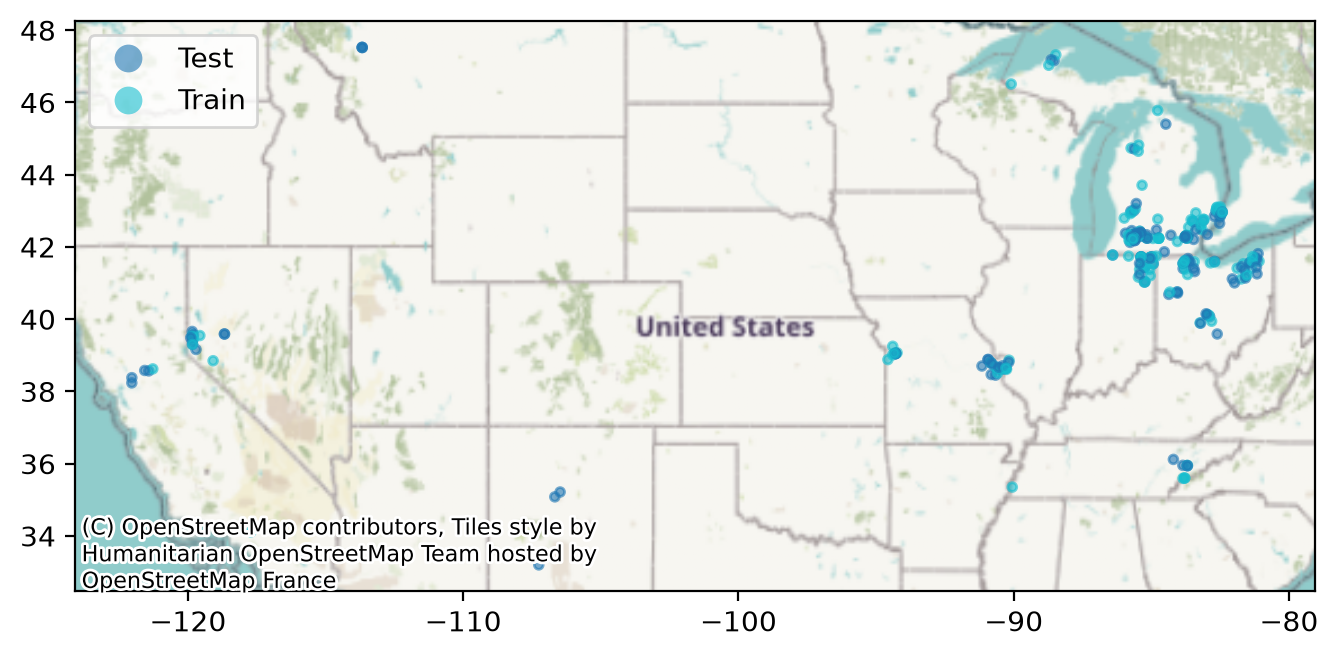

In [44]:
# plot map of points colored by test/train split
import geopandas as gpd
import matplotlib.pyplot as plt
import contextily as ctx

gdf = gpd.GeoDataFrame(
    points.to_pandas(),
    geometry=gpd.points_from_xy(points["lon"], points["lat"]),
    crs="EPSG:4326",
)
gdf["test_split_label"] = gdf["test_split"].map({True: "Test", False: "Train"})

gdf.plot(column="test_split_label", legend=True, markersize=10,alpha=0.6, figsize=(8, 6))
ctx.add_basemap(plt.gca(), crs=gdf.crs.to_string())


write the data and point files

In [49]:
data_root = Path('../datasets/')
combined_with_lidar.write_csv(data_root / "butterflies/species_observations.csv")
points.write_csv(data_root / "butterflies/site_list.csv")